# 🍎🍌🍊 水果影像分類 — KNN & SVM 機器學習專題

**Fruit Image Classification using K-Nearest Neighbors & Support Vector Machine**

---

## 專題目標
以**監督式學習**方式，使用 **KNN** 與 **SVM** 兩種演算法，訓練能辨識三種水果的模型：

| 類別 | 水果 | 影像數 (訓練) |
|------|------|----------|
| 0 | 🍎 Apple (蘋果) | ≥ 60 張 |
| 1 | 🍌 Banana (香蕉) | ≥ 60 張 |
| 2 | 🍊 Orange (柳橙) | ≥ 60 張 |

## 評估指標
- **Accuracy** — 整體準確率
- **Precision** — 精確率 (weighted)
- **F1 Score** — 調和平均數 (weighted)

## 資料集
[Fruits-360](https://github.com/Horea94/Fruit-Images-Dataset) — 100×100 像素水果影像，每類數百張

---
**作者**: AI 機器學習課程 期中專題  |  **工具**: Google Colab + scikit-learn

## 第一節：環境設定 (Environment Setup)

In [1]:
# 安裝必要套件 (Install required packages)
!pip install scikit-image==0.21.0 opencv-python-headless joblib -q
print('Installation complete.')

Installation complete.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
import json
import time
import shutil
import subprocess
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import joblib
import sklearn

from PIL import Image
from skimage.feature import hog
from skimage import exposure

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline

# ---------- Global settings ----------
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')

FRUIT_LABELS   = ['apple', 'banana', 'orange', 'watermelon']
FRUIT_EMOJI    = {'apple': '🍎', 'banana': '🍌', 'orange': '🍊', 'watermelon': '🍉'}
FRUIT_FOLDERS  = ['Apple Braeburn', 'Banana', 'Orange', 'Watermelon']  # Fruits-360 names
IMG_SIZE       = (64, 64)
MAX_PER_CLASS  = 80    # up to 80 training images per class
MAX_TEST       = 35    # up to 35 test images per class
CONFIDENCE_THRESHOLD = 0.52   # max prob below this → 無此項目 (Unknown / OOD)

print('✅ 所有套件載入成功!')
print(f'   Python      : {sys.version.split()[0]}')
print(f'   NumPy       : {np.__version__}')
print(f'   scikit-learn: {sklearn.__version__}')
print(f'   OpenCV      : {cv2.__version__}')
print(f'\n分類目標: {[FRUIT_EMOJI[l]+" "+l for l in FRUIT_LABELS]}')
print(f'信心度門檻: {CONFIDENCE_THRESHOLD:.0%}  (低於此值 → 無此項目)')

✅ 所有套件載入成功!
   Python      : 3.12.1
   NumPy       : 1.26.4
   scikit-learn: 1.8.0
   OpenCV      : 4.11.0

分類目標: ['🍎 apple', '🍌 banana', '🍊 orange', '🍉 watermelon']
信心度門檻: 52%  (低於此值 → 無此項目)


## 第二節：資料集下載 (Dataset Download)

使用 **git sparse-checkout** 從 [Fruits-360 GitHub](https://github.com/Horea94/Fruit-Images-Dataset) 下載
三種水果的子集，無需 API 金鑰。

> 若網路無法連線，請改用下方 **Kaggle** 備用方案，或手動上傳影像。

In [3]:
REPO_DIR  = 'fruits_repo'
REPO_URL  = 'https://github.com/Horea94/Fruit-Images-Dataset.git'

def run(cmd, **kwargs):
    """Run shell command and return (returncode, stdout+stderr)."""
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, **kwargs)
    return r.returncode, r.stdout + r.stderr

def download_fruits360_sparse():
    """Download only the three fruit folders via git sparse-checkout."""
    if os.path.exists(REPO_DIR):
        print(f'📁 {REPO_DIR}/ 已存在，略過下載。')
        return True

    print('📥 git sparse-checkout 下載中 (約 20–60 MB)...')
    print('   請稍候，依網路速度約需 1–3 分鐘。')

    sparse_paths = []
    for folder in FRUIT_FOLDERS:
        sparse_paths += [f'Training/{folder}', f'Test/{folder}']

    cmds = [
        f'git clone --depth 1 --filter=blob:none --no-checkout {REPO_URL} {REPO_DIR}',
        f'cd {REPO_DIR} && git sparse-checkout init --cone',
        f'cd {REPO_DIR} && git sparse-checkout set ' + ' '.join(f'"{p}"' for p in sparse_paths),
        f'cd {REPO_DIR} && git checkout',
    ]

    for cmd in cmds:
        code, out = run(cmd)
        if code != 0 and 'already exists' not in out:
            print(f'   ⚠️  命令失敗 (code={code}): {cmd[:60]}...')
            print(f'   {out[-300:]}')
            return False

    return True

ok = download_fruits360_sparse()

if ok:
    print('\n✅ 下載成功！目錄結構:')
    for split in ['Training', 'Test']:
        for folder in FRUIT_FOLDERS:
            path = f'{REPO_DIR}/{split}/{folder}'
            if os.path.exists(path):
                n = len([f for f in os.listdir(path) if f.endswith('.jpg')])
                print(f'   {split}/{folder}: {n} 張影像')
else:
    print('❌ 自動下載失敗。請使用下方 Kaggle 備用方案或手動上傳。')

📁 fruits_repo/ 已存在，略過下載。

✅ 下載成功！目錄結構:
   Training/Apple Braeburn: 492 張影像
   Training/Banana: 490 張影像
   Training/Orange: 479 張影像
   Training/Watermelon: 475 張影像
   Test/Apple Braeburn: 164 張影像
   Test/Banana: 166 張影像
   Test/Orange: 160 張影像
   Test/Watermelon: 157 張影像


In [4]:
# ============================================================
#  (選用) Kaggle 備用下載方案
#  若上方 git 下載失敗，在此輸入 Kaggle 憑證後執行此儲存格
# ============================================================
USE_KAGGLE = False   # ← 改為 True 以啟用

if USE_KAGGLE:
    import os
    os.environ['KAGGLE_USERNAME'] = 'YOUR_USERNAME'   # ← 填入你的 Kaggle 帳號
    os.environ['KAGGLE_KEY']      = 'YOUR_API_KEY'    # ← 填入你的 Kaggle API Key

    !pip install kaggle -q
    !kaggle datasets download -d moltean/fruits -p . --unzip

    # Remap folder paths to REPO_DIR structure
    import shutil
    for split, kaggle_split in [('Training', 'Training'), ('Test', 'Test')]:
        for folder in FRUIT_FOLDERS:
            src = f'fruits-360/{kaggle_split}/{folder}'
            dst = f'{REPO_DIR}/{split}/{folder}'
            if os.path.exists(src) and not os.path.exists(dst):
                os.makedirs(os.path.dirname(dst), exist_ok=True)
                shutil.copytree(src, dst)
    print('✅ Kaggle 資料集已整理完畢。')
else:
    print('ℹ️  Kaggle 備用方案已停用 (USE_KAGGLE=False)。')

ℹ️  Kaggle 備用方案已停用 (USE_KAGGLE=False)。


## 第三節：資料載入與探索 (Data Loading & EDA)

In [5]:
def load_images_from_folder(folder_path, label, img_size=IMG_SIZE, max_n=80):
    """讀取資料夾內的影像，回傳 (images list, labels list)."""
    images, labels = [], []
    if not os.path.exists(folder_path):
        print(f'  ⚠️  目錄不存在: {folder_path}')
        return images, labels
    files = sorted(f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    for fname in files[:max_n]:
        img = cv2.imread(os.path.join(folder_path, fname))
        if img is not None:
            img = cv2.resize(img, img_size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(label)
    return images, labels

# ---- Load Training Data ----
print('📦 載入訓練資料...')
X_raw_all, y_raw_all = [], []
for idx, folder in enumerate(FRUIT_FOLDERS):
    imgs, lbs = load_images_from_folder(
        f'{REPO_DIR}/Training/{folder}', idx, max_n=MAX_PER_CLASS
    )
    X_raw_all.extend(imgs)
    y_raw_all.extend(lbs)
    print(f'  ✅ {FRUIT_LABELS[idx]:8s}: {len(imgs):3d} 張訓練影像')

X_raw = np.array(X_raw_all)
y_raw = np.array(y_raw_all)

# ---- Load Test Data ----
print('\n📦 載入測試資料...')
X_test_raw_all, y_test_raw_all = [], []
for idx, folder in enumerate(FRUIT_FOLDERS):
    imgs, lbs = load_images_from_folder(
        f'{REPO_DIR}/Test/{folder}', idx, max_n=MAX_TEST
    )
    X_test_raw_all.extend(imgs)
    y_test_raw_all.extend(lbs)
    print(f'  ✅ {FRUIT_LABELS[idx]:8s}: {len(imgs):3d} 張測試影像')

X_test_raw  = np.array(X_test_raw_all)
y_test_raw  = np.array(y_test_raw_all)

print(f'\n📊 資料集統計:')
print(f'  訓練集: {X_raw.shape[0]} 張 | 影像尺寸: {X_raw.shape[1]}×{X_raw.shape[2]}')
print(f'  測試集: {X_test_raw.shape[0]} 張')
assert X_raw.shape[0] >= 3 * 40, '⚠️  訓練影像不足 — 每類至少需要 40 張！'

📦 載入訓練資料...
  ✅ apple   :  80 張訓練影像
  ✅ banana  :  80 張訓練影像
  ✅ orange  :  80 張訓練影像
  ✅ watermelon:  80 張訓練影像

📦 載入測試資料...
  ✅ apple   :  35 張測試影像
  ✅ banana  :  35 張測試影像
  ✅ orange  :  35 張測試影像
  ✅ watermelon:  35 張測試影像

📊 資料集統計:
  訓練集: 320 張 | 影像尺寸: 64×64
  測試集: 140 張


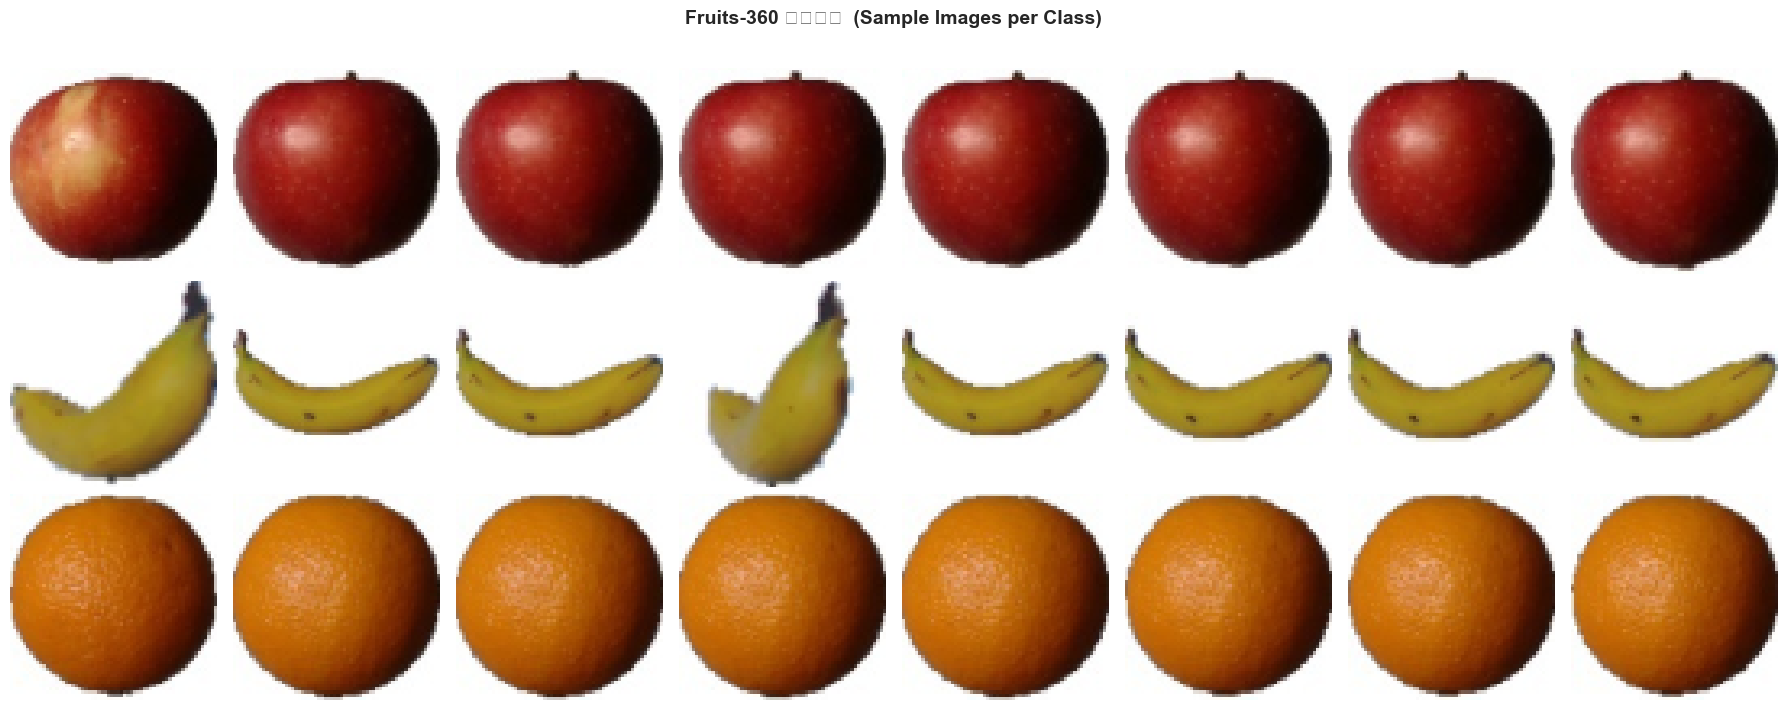

圖片已儲存: sample_images.png


In [6]:
# ---- Sample Image Grid ----
N_SHOW = 8
fig, axes = plt.subplots(3, N_SHOW, figsize=(18, 7))
fig.suptitle('Fruits-360 影像樣本  (Sample Images per Class)', fontsize=14, fontweight='bold', y=1.01)

for cls in range(3):
    idxs = np.where(y_raw == cls)[0][:N_SHOW]
    for col, i in enumerate(idxs):
        axes[cls, col].imshow(X_raw[i])
        axes[cls, col].axis('off')
        if col == 0:
            axes[cls, col].set_ylabel(
                f'{FRUIT_EMOJI[FRUIT_LABELS[cls]]} {FRUIT_LABELS[cls]}',
                fontsize=12, fontweight='bold', rotation=0,
                labelpad=60, va='center'
            )

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('圖片已儲存: sample_images.png')

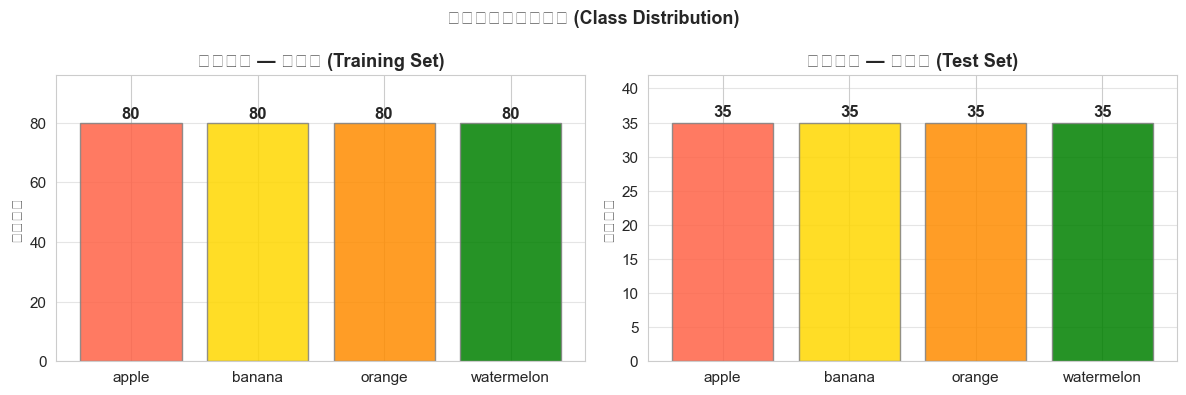

In [7]:
# ---- Class Distribution ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (y_data, title) in zip(
    axes,
    [(y_raw, '訓練集 (Training Set)'), (y_test_raw, '測試集 (Test Set)')]
):
    counts = [np.sum(y_data == i) for i in range(len(FRUIT_LABELS))]

    bars = ax.bar(
        FRUIT_LABELS, counts,
        color=['tomato', 'gold', 'darkorange', 'green'],

        edgecolor='gray', alpha=0.85
    )
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_title(f'類別分布 — {title}', fontweight='bold')
    ax.set_ylabel('影像數量')
    ax.set_ylim(0, max(counts) * 1.2)
    ax.grid(axis='y', alpha=0.5)

plt.suptitle('各類別影像數量分布 (Class Distribution)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 第四節：特徵工程 (Feature Engineering)

KNN / SVM 為傳統機器學習演算法，需手動提取特徵。本專題結合兩類特徵：

| 特徵 | 維度 | 說明 |
|------|------|------|
| HOG (方向梯度直方圖) | ~1764 | 描述形狀與紋理 |
| RGB 顏色直方圖 | 96 | 各通道 32 bins，正規化 |
| HSV 顏色直方圖 | 50 | Hue 18 bins + Saturation 32 bins，正規化 |
| **合計** | **~1910** | |

In [8]:
def extract_features(images, verbose=False):
    """Extract HOG + colour histogram features from a list of RGB images."""
    features = []
    t0 = time.time()
    for i, img in enumerate(images):
        # 1. HOG — shape / texture
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hog_feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            visualize=False,
            feature_vector=True
        )
        # 2. RGB colour histogram
        hist_r = np.histogram(img[:, :, 0], bins=32, range=(0, 256))[0]
        hist_g = np.histogram(img[:, :, 1], bins=32, range=(0, 256))[0]
        hist_b = np.histogram(img[:, :, 2], bins=32, range=(0, 256))[0]
        color_rgb = np.concatenate([hist_r, hist_g, hist_b]).astype(float)
        color_rgb /= color_rgb.sum() + 1e-7

        # 3. HSV colour histogram
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        hist_h = np.histogram(hsv[:, :, 0], bins=18, range=(0, 180))[0]
        hist_s = np.histogram(hsv[:, :, 1], bins=32, range=(0, 256))[0]
        color_hsv = np.concatenate([hist_h, hist_s]).astype(float)
        color_hsv /= color_hsv.sum() + 1e-7

        features.append(np.concatenate([hog_feat, color_rgb, color_hsv]))

        if verbose and (i + 1) % 50 == 0:
            print(f'  提取特徵: {i+1}/{len(images)} ({time.time()-t0:.1f}s)')

    return np.array(features)


print('🔧 提取訓練集特徵...')
X_feat      = extract_features(X_raw, verbose=True)
print('🔧 提取測試集特徵...')
X_test_feat = extract_features(X_test_raw, verbose=True)

print(f'\n✅ 特徵提取完成!')
print(f'   訓練集特徵矩陣: {X_feat.shape}')
print(f'   測試集特徵矩陣: {X_test_feat.shape}')

🔧 提取訓練集特徵...
  提取特徵: 50/320 (0.2s)
  提取特徵: 100/320 (0.3s)
  提取特徵: 150/320 (0.5s)
  提取特徵: 200/320 (0.6s)
  提取特徵: 250/320 (0.7s)
  提取特徵: 300/320 (0.9s)
🔧 提取測試集特徵...
  提取特徵: 50/140 (0.1s)
  提取特徵: 100/140 (0.3s)

✅ 特徵提取完成!
   訓練集特徵矩陣: (320, 1910)
   測試集特徵矩陣: (140, 1910)


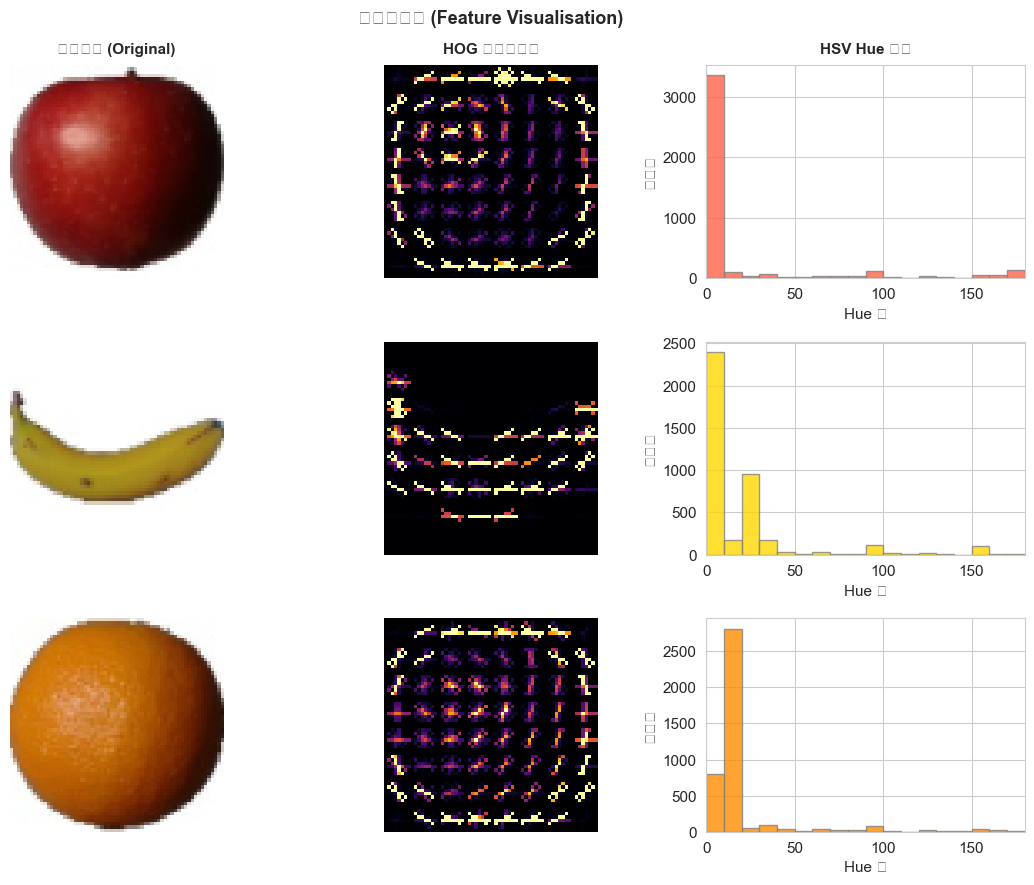

In [9]:
# ---- HOG Visualisation ----
fig, axes = plt.subplots(3, 3, figsize=(11, 9))
col_titles = ['原始影像 (Original)', 'HOG 特徵視覺化', 'HSV Hue 分布']
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=11, fontweight='bold', pad=8)

hue_colors = ['tomato', 'gold', 'darkorange']

for cls in range(3):
    idx  = np.where(y_raw == cls)[0][2]   # pick 3rd sample
    img  = X_raw[idx]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, hog_img = hog(gray, orientations=9, pixels_per_cell=(8,8),
                     cells_per_block=(2,2), visualize=True, feature_vector=True)
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    hsv     = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    axes[cls, 0].imshow(img)
    axes[cls, 0].axis('off')
    axes[cls, 0].set_ylabel(
        f'{FRUIT_EMOJI[FRUIT_LABELS[cls]]} {FRUIT_LABELS[cls]}',
        fontsize=12, fontweight='bold', rotation=0, labelpad=55, va='center'
    )

    axes[cls, 1].imshow(hog_img, cmap='inferno')
    axes[cls, 1].axis('off')

    axes[cls, 2].hist(hsv[:,:,0].flatten(), bins=18, range=(0,180),
                      color=hue_colors[cls], alpha=0.8, edgecolor='gray')
    axes[cls, 2].set_xlim(0, 180)
    axes[cls, 2].set_xlabel('Hue 值')
    axes[cls, 2].set_ylabel('像素數')

plt.suptitle('特徵視覺化 (Feature Visualisation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_visualisation.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
# ---- Train / Validation Split + Feature Scaling ----
X_train, X_val, y_train, y_val = train_test_split(
    X_feat, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_val_sc      = scaler.transform(X_val)
X_test_sc     = scaler.transform(X_test_feat)

print('📊 資料集分割結果:')
print(f'   訓練集: {X_train_sc.shape[0]} 樣本')
print(f'   驗證集: {X_val_sc.shape[0]} 樣本')
print(f'   測試集: {X_test_sc.shape[0]} 樣本')
print(f'   特徵維度: {X_train_sc.shape[1]}')

print('\n訓練集類別分布:')
for i, name in enumerate(FRUIT_LABELS):
    n = np.sum(y_train == i)
    print(f'   {FRUIT_EMOJI[name]} {name}: {n} 樣本   (需 ≥ 40 ✅)')

📊 資料集分割結果:
   訓練集: 256 樣本
   驗證集: 64 樣本
   測試集: 140 樣本
   特徵維度: 1910

訓練集類別分布:
   🍎 apple: 64 樣本   (需 ≥ 40 ✅)
   🍌 banana: 64 樣本   (需 ≥ 40 ✅)
   🍊 orange: 64 樣本   (需 ≥ 40 ✅)
   🍉 watermelon: 64 樣本   (需 ≥ 40 ✅)


## 第五節：KNN 演算法訓練 (K-Nearest Neighbors)

使用 **5-fold 交叉驗證** 在 K = 1 ~ 30 之間尋找最佳鄰近數，
再以最佳 K 訓練最終模型並評估。

In [11]:
print('=' * 60)
print('  KNN 訓練 — 超參數調整 (K Value Selection)')
print('=' * 60)

K_RANGE       = range(1, 31)
cv5           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_mean       = []
cv_std        = []
train_acc_knn = []
val_acc_knn   = []

t0 = time.time()
print(f'\n  K 值測試 ({len(list(K_RANGE))} 個值, 5-fold CV)...')

for k in K_RANGE:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=cv5, scoring='accuracy', n_jobs=-1)
    cv_mean.append(scores.mean())
    cv_std.append(scores.std())
    knn.fit(X_train_sc, y_train)
    train_acc_knn.append(knn.score(X_train_sc, y_train))
    val_acc_knn.append(knn.score(X_val_sc, y_val))

best_k = K_RANGE[int(np.argmax(cv_mean))]
print(f'\n✅ 搜索完成 ({time.time()-t0:.1f}s)')
print(f'   最佳 K 值:          K = {best_k}')
print(f'   最佳 CV Accuracy:   {max(cv_mean):.4f}')

  KNN 訓練 — 超參數調整 (K Value Selection)

  K 值測試 (30 個值, 5-fold CV)...

✅ 搜索完成 (19.8s)
   最佳 K 值:          K = 1
   最佳 CV Accuracy:   0.9961


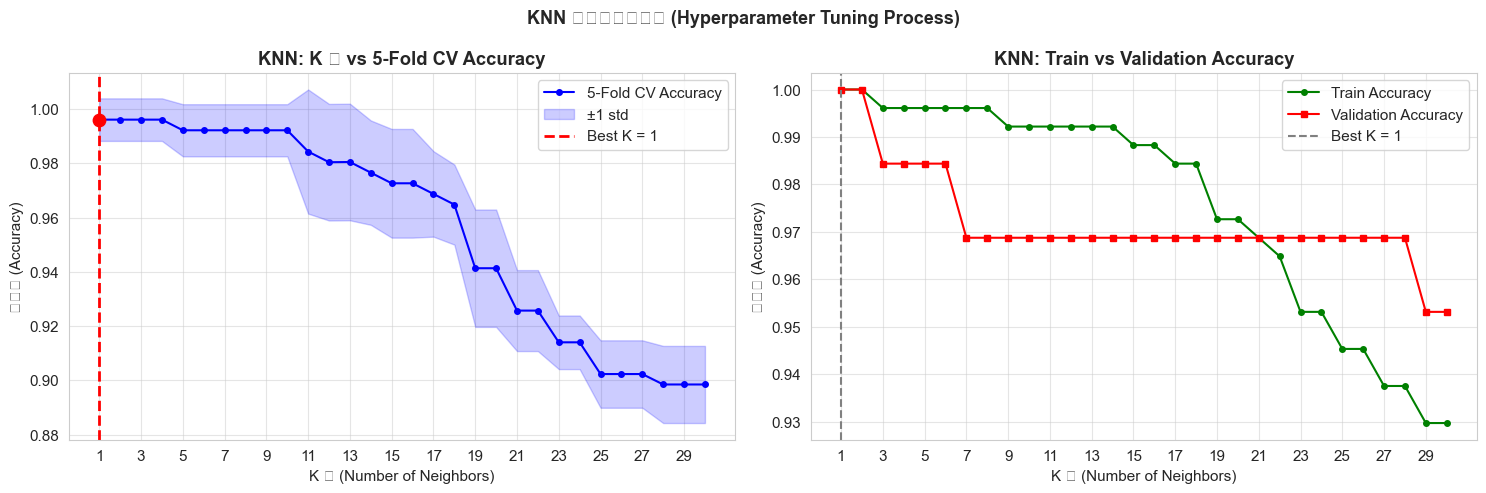

In [12]:
# ---- K Selection Plot ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: CV accuracy + confidence band
k_vals = list(K_RANGE)
axes[0].plot(k_vals, cv_mean, 'b-o', markersize=4, linewidth=1.5, label='5-Fold CV Accuracy')
axes[0].fill_between(
    k_vals,
    np.array(cv_mean) - np.array(cv_std),
    np.array(cv_mean) + np.array(cv_std),
    alpha=0.2, color='blue', label='±1 std'
)
axes[0].axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Best K = {best_k}')
axes[0].scatter([best_k], [cv_mean[best_k-1]], color='red', s=80, zorder=5)
axes[0].set_xlabel('K 值 (Number of Neighbors)')
axes[0].set_ylabel('準確率 (Accuracy)')
axes[0].set_title('KNN: K 值 vs 5-Fold CV Accuracy', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, 31, 2))
axes[0].grid(True, alpha=0.5)

# Right: Train vs Validation accuracy
axes[1].plot(k_vals, train_acc_knn, 'g-o', markersize=4, linewidth=1.5, label='Train Accuracy')
axes[1].plot(k_vals, val_acc_knn,   'r-s', markersize=4, linewidth=1.5, label='Validation Accuracy')
axes[1].axvline(x=best_k, color='gray', linestyle='--', linewidth=1.5, label=f'Best K = {best_k}')
axes[1].set_xlabel('K 值 (Number of Neighbors)')
axes[1].set_ylabel('準確率 (Accuracy)')
axes[1].set_title('KNN: Train vs Validation Accuracy', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(1, 31, 2))
axes[1].grid(True, alpha=0.5)

plt.suptitle('KNN 超參數調整過程 (Hyperparameter Tuning Process)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=100, bbox_inches='tight')
plt.show()

In [13]:
# ---- Final KNN Model ----
print(f'🏋️  使用最佳 K = {best_k} 訓練最終 KNN 模型...')
knn_final = KNeighborsClassifier(
    n_neighbors=best_k, metric='euclidean', weights='distance', n_jobs=-1
)
knn_final.fit(X_train_sc, y_train)

# Predictions
y_pred_knn = knn_final.predict(X_test_sc)

# Metrics
knn_acc  = accuracy_score(y_test_raw, y_pred_knn)
knn_prec = precision_score(y_test_raw, y_pred_knn, average='weighted', zero_division=0)
knn_rec  = recall_score(y_test_raw, y_pred_knn, average='weighted', zero_division=0)
knn_f1   = f1_score(y_test_raw, y_pred_knn, average='weighted', zero_division=0)

print('\n' + '=' * 52)
print('  📊 KNN 測試集評估結果')
print('=' * 52)
print(f'  最佳 K 值   : {best_k}')
print(f'  Accuracy    : {knn_acc:.4f}   ({knn_acc*100:.2f}%)')
print(f'  Precision   : {knn_prec:.4f}')
print(f'  Recall      : {knn_rec:.4f}')
print(f'  F1 Score    : {knn_f1:.4f}')
print('=' * 52)
print('\n  📋 詳細分類報告 (Classification Report):')
print(classification_report(y_test_raw, y_pred_knn, target_names=FRUIT_LABELS))

🏋️  使用最佳 K = 1 訓練最終 KNN 模型...

  📊 KNN 測試集評估結果
  最佳 K 值   : 1
  Accuracy    : 0.9929   (99.29%)
  Precision   : 0.9931
  Recall      : 0.9929
  F1 Score    : 0.9929

  📋 詳細分類報告 (Classification Report):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        35
      banana       1.00      0.97      0.99        35
      orange       1.00      1.00      1.00        35
  watermelon       0.97      1.00      0.99        35

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140



In [14]:
print(FRUIT_FOLDERS)


['Apple Braeburn', 'Banana', 'Orange', 'Watermelon']


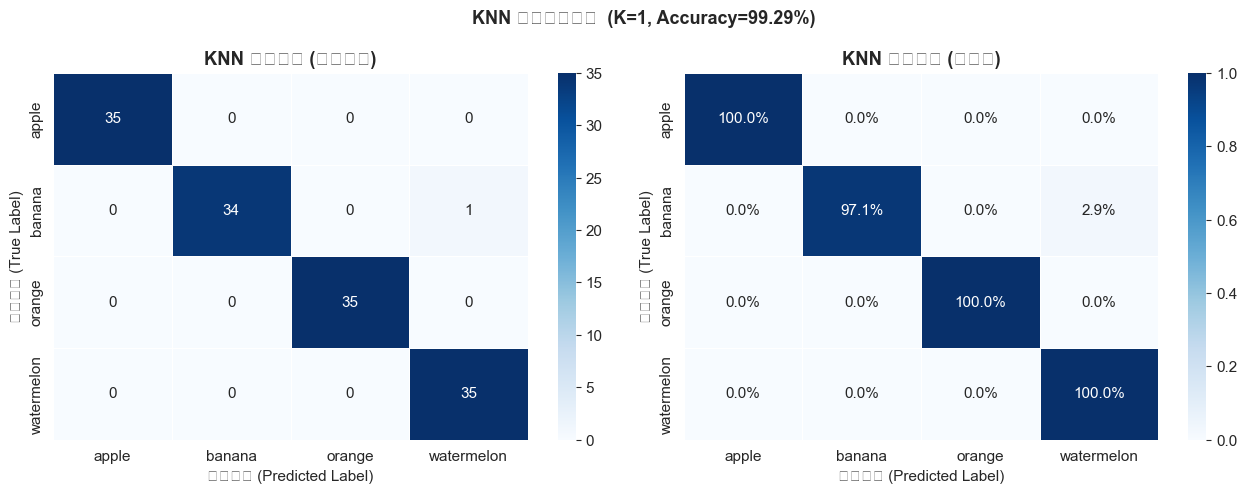

In [15]:
# ---- KNN Confusion Matrix ----
cm_knn = confusion_matrix(y_test_raw, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=FRUIT_LABELS, yticklabels=FRUIT_LABELS,
            ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title('KNN 混淆矩陣 (原始計數)', fontweight='bold')
axes[0].set_ylabel('真實標籤 (True Label)')
axes[0].set_xlabel('預測標籤 (Predicted Label)')

cm_knn_n = cm_knn.astype('float') / cm_knn.sum(axis=1, keepdims=True)
sns.heatmap(cm_knn_n, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=FRUIT_LABELS, yticklabels=FRUIT_LABELS,
            ax=axes[1], linewidths=0.5, linecolor='white')
axes[1].set_title('KNN 混淆矩陣 (正規化)', fontweight='bold')
axes[1].set_ylabel('真實標籤 (True Label)')
axes[1].set_xlabel('預測標籤 (Predicted Label)')

plt.suptitle(f'KNN 混淆矩陣分析  (K={best_k}, Accuracy={knn_acc:.2%})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## 第六節：SVM 演算法訓練 (Support Vector Machine)

對 **Linear** 與 **RBF** 核函數進行 **GridSearchCV** 超參數搜索，
以 5-fold 交叉驗證選出最佳組合。

In [16]:
print('=' * 60)
print('  SVM 訓練 — Grid Search 超參數搜索')
print('=' * 60)

param_grid = [
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10]},
    {'kernel': ['rbf'],    'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01]},
]

print('\n  測試參數:')
print('  Linear SVM : C = [0.01, 0.1, 1, 10]')
print('  RBF SVM    : C = [0.1, 1, 10, 100]  × gamma = [scale, auto, 0.001, 0.01]')
print('  交叉驗證   : 5-fold')

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

t0 = time.time()
print('\n  執行 Grid Search...')
svm_grid.fit(X_train_sc, y_train)
elapsed = time.time() - t0

print(f'\n✅ Grid Search 完成! 耗時: {elapsed:.1f} 秒')
print(f'   最佳參數    : {svm_grid.best_params_}')
print(f'   最佳 CV Acc : {svm_grid.best_score_:.4f}')

  SVM 訓練 — Grid Search 超參數搜索

  測試參數:
  Linear SVM : C = [0.01, 0.1, 1, 10]
  RBF SVM    : C = [0.1, 1, 10, 100]  × gamma = [scale, auto, 0.001, 0.01]
  交叉驗證   : 5-fold

  執行 Grid Search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Grid Search 完成! 耗時: 3.7 秒
   最佳參數    : {'C': 0.01, 'kernel': 'linear'}
   最佳 CV Acc : 1.0000


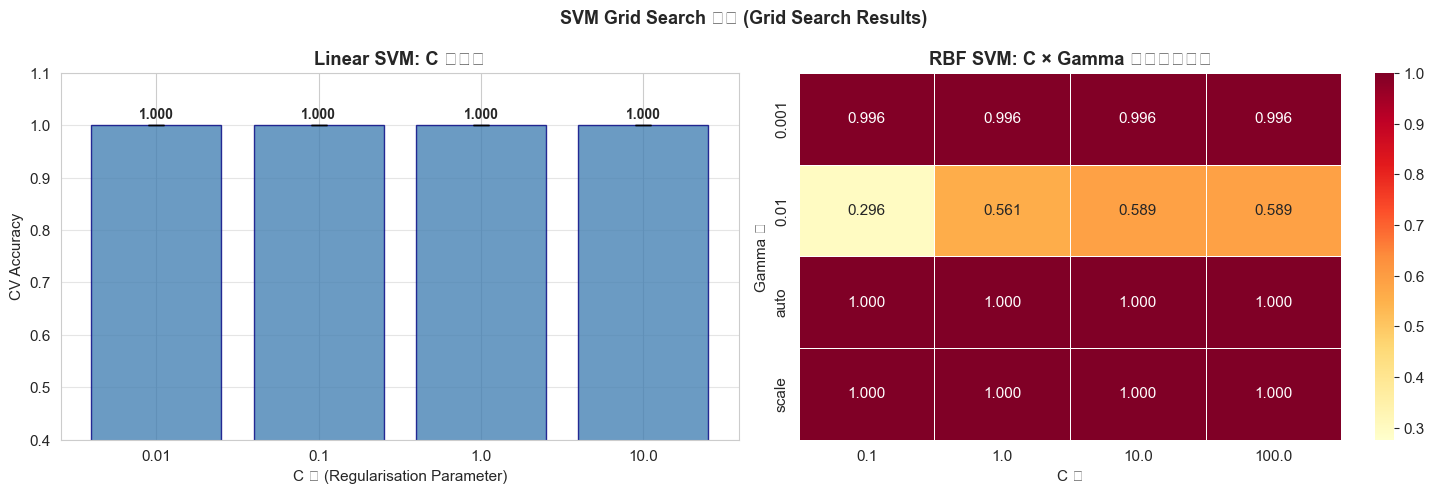

In [17]:
# ---- Grid Search Visualisation ----
cv_df = pd.DataFrame(svm_grid.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Linear SVM — C vs Accuracy
lin_df = cv_df[cv_df['param_kernel'] == 'linear'].copy()
if not lin_df.empty:
    lin_df = lin_df.sort_values('param_C')
    c_labels = [str(c) for c in lin_df['param_C']]
    bars = axes[0].bar(
        c_labels, lin_df['mean_test_score'],
        yerr=lin_df['std_test_score'],
        color='steelblue', alpha=0.8, edgecolor='navy', capsize=6
    )
    for bar, v in zip(bars, lin_df['mean_test_score']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[0].set_xlabel('C 值 (Regularisation Parameter)')
    axes[0].set_ylabel('CV Accuracy')
    axes[0].set_title('Linear SVM: C 值調整', fontweight='bold')
    axes[0].set_ylim(0.4, 1.1)
    axes[0].grid(axis='y', alpha=0.5)

# Right: RBF SVM — C × gamma heatmap
rbf_df = cv_df[cv_df['param_kernel'] == 'rbf'].copy()
if not rbf_df.empty:
    rbf_df['param_gamma_str'] = rbf_df['param_gamma'].astype(str)
    try:
        pivot = rbf_df.pivot_table(
            values='mean_test_score',
            index='param_gamma_str',
            columns='param_C'
        )
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                    ax=axes[1], linewidths=0.5, linecolor='white',
                    vmin=pivot.values.min()-0.02, vmax=1.0)
        axes[1].set_title('RBF SVM: C × Gamma 準確率熱力圖', fontweight='bold')
        axes[1].set_xlabel('C 值')
        axes[1].set_ylabel('Gamma 值')
    except Exception:
        axes[1].text(0.5, 0.5, 'RBF heatmap unavailable', transform=axes[1].transAxes,
                     ha='center', va='center')

plt.suptitle('SVM Grid Search 結果 (Grid Search Results)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_gridsearch.png', dpi=100, bbox_inches='tight')
plt.show()

In [18]:
# ---- Final SVM Evaluation ----
svm_final   = svm_grid.best_estimator_
y_pred_svm  = svm_final.predict(X_test_sc)

svm_acc  = accuracy_score(y_test_raw, y_pred_svm)
svm_prec = precision_score(y_test_raw, y_pred_svm, average='weighted', zero_division=0)
svm_rec  = recall_score(y_test_raw, y_pred_svm, average='weighted', zero_division=0)
svm_f1   = f1_score(y_test_raw, y_pred_svm, average='weighted', zero_division=0)

print('\n' + '=' * 52)
print('  📊 SVM 測試集評估結果')
print('=' * 52)
print(f'  最佳參數    : {svm_grid.best_params_}')
print(f'  Accuracy    : {svm_acc:.4f}   ({svm_acc*100:.2f}%)')
print(f'  Precision   : {svm_prec:.4f}')
print(f'  Recall      : {svm_rec:.4f}')
print(f'  F1 Score    : {svm_f1:.4f}')
print('=' * 52)
print('\n  📋 詳細分類報告 (Classification Report):')
print(classification_report(y_test_raw, y_pred_svm, target_names=FRUIT_LABELS))


  📊 SVM 測試集評估結果
  最佳參數    : {'C': 0.01, 'kernel': 'linear'}
  Accuracy    : 1.0000   (100.00%)
  Precision   : 1.0000
  Recall      : 1.0000
  F1 Score    : 1.0000

  📋 詳細分類報告 (Classification Report):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        35
      banana       1.00      1.00      1.00        35
      orange       1.00      1.00      1.00        35
  watermelon       1.00      1.00      1.00        35

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



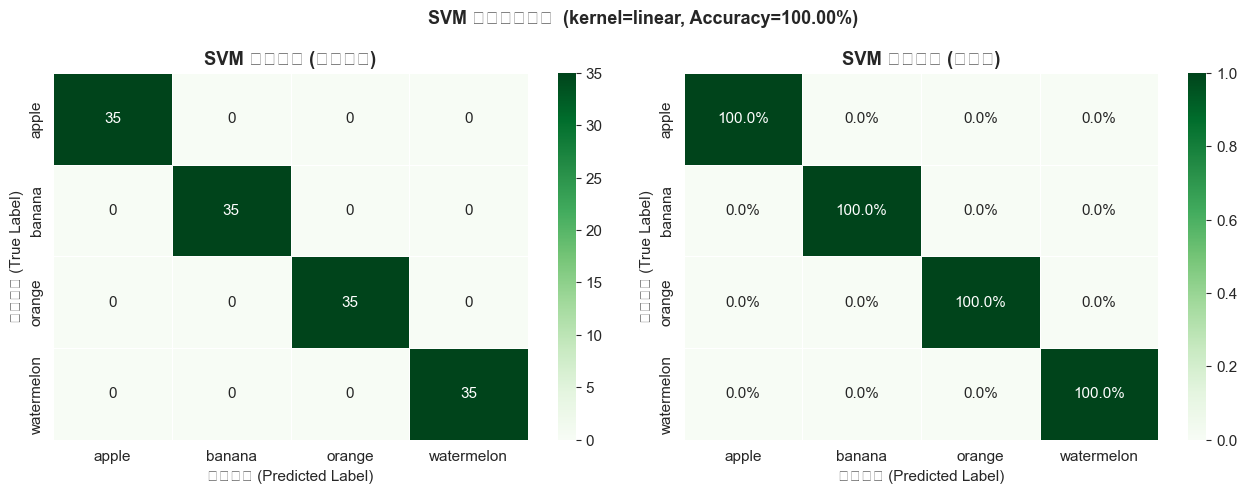

In [19]:
# ---- SVM Confusion Matrix ----
cm_svm = confusion_matrix(y_test_raw, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=FRUIT_LABELS, yticklabels=FRUIT_LABELS,
            ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title('SVM 混淆矩陣 (原始計數)', fontweight='bold')
axes[0].set_ylabel('真實標籤 (True Label)')
axes[0].set_xlabel('預測標籤 (Predicted Label)')

cm_svm_n = cm_svm.astype('float') / cm_svm.sum(axis=1, keepdims=True)
sns.heatmap(cm_svm_n, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=FRUIT_LABELS, yticklabels=FRUIT_LABELS,
            ax=axes[1], linewidths=0.5, linecolor='white')
axes[1].set_title('SVM 混淆矩陣 (正規化)', fontweight='bold')
axes[1].set_ylabel('真實標籤 (True Label)')
axes[1].set_xlabel('預測標籤 (Predicted Label)')

best_svm_params = svm_grid.best_params_
plt.suptitle(f'SVM 混淆矩陣分析  (kernel={best_svm_params["kernel"]}, Accuracy={svm_acc:.2%})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## 第七節：訓練曲線 (Learning Curves)

展示兩個模型隨訓練樣本數增加時的表現變化，幫助判斷是否存在過擬合 (overfitting) 或欠擬合 (underfitting)。

📈 繪製訓練曲線 (需要一點時間)...


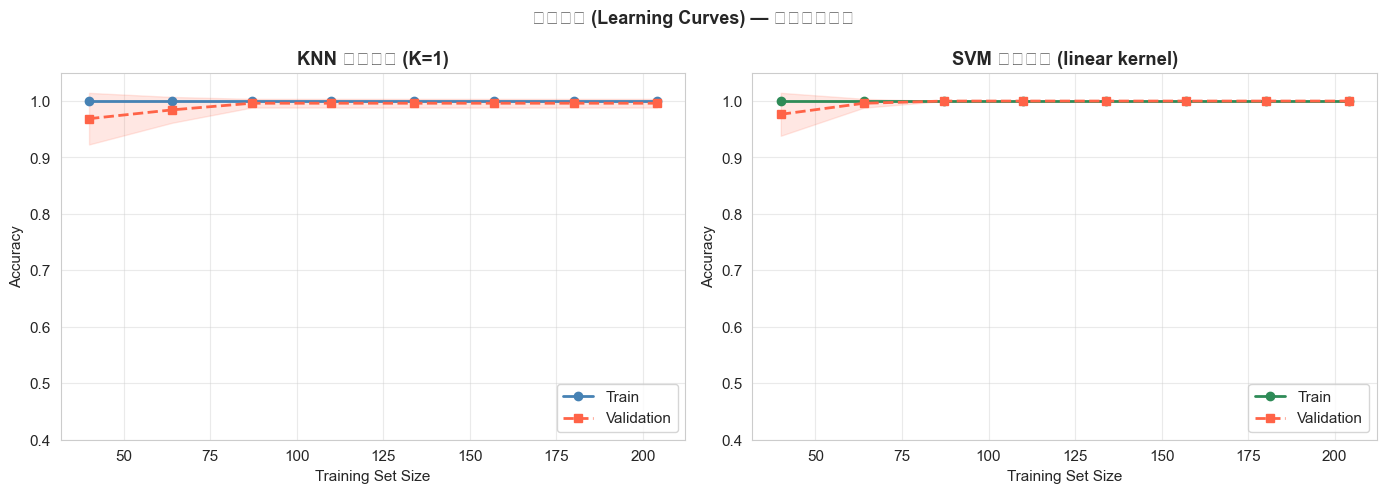

✅ 學習曲線完成


In [20]:
def plot_learning_curve(estimator, title, X, y, ax, cv=5, color='steelblue'):
    """Plot sklearn learning_curve on given axes."""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=np.linspace(0.2, 1.0, 8),
        cv=cv, scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42
    )
    t_mean = train_scores.mean(axis=1)
    t_std  = train_scores.std(axis=1)
    v_mean = val_scores.mean(axis=1)
    v_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, t_mean, 'o-', color=color,     linewidth=2, label='Train')
    ax.plot(train_sizes, v_mean, 's--', color='tomato', linewidth=2, label='Validation')
    ax.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color=color)
    ax.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='tomato')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.set_ylim(0.4, 1.05)
    ax.grid(True, alpha=0.4)


print('📈 繪製訓練曲線 (需要一點時間)...')

knn_lc = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean',
                               weights='distance', n_jobs=-1)
svm_lc = SVC(**svm_grid.best_params_, random_state=42, probability=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_learning_curve(knn_lc, f'KNN 訓練曲線 (K={best_k})', X_train_sc, y_train, axes[0], color='steelblue')
plot_learning_curve(svm_lc, f'SVM 訓練曲線 ({svm_grid.best_params_["kernel"]} kernel)', X_train_sc, y_train, axes[1], color='seagreen')

plt.suptitle('訓練曲線 (Learning Curves) — 訓練過程展示', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ 學習曲線完成')

## 第八節：模型比較 (Model Comparison)

In [21]:
# ---- Summary Table ----
results = pd.DataFrame({
    'Model'    : ['KNN', 'SVM'],
    'Accuracy' : [knn_acc,  svm_acc],
    'Precision': [knn_prec, svm_prec],
    'Recall'   : [knn_rec,  svm_rec],
    'F1 Score' : [knn_f1,   svm_f1],
})

print('\n' + '=' * 62)
print('  🏆 最終模型比較結果 (Final Model Comparison)')
print('=' * 62)
print(results.to_string(index=False, float_format='{:.4f}'.format))
print('=' * 62)

best_model = 'SVM' if svm_f1 >= knn_f1 else 'KNN'
print(f'\n  🥇 F1 Score 最佳模型: {best_model}')


  🏆 最終模型比較結果 (Final Model Comparison)
Model  Accuracy  Precision  Recall  F1 Score
  KNN    0.9929     0.9931  0.9929    0.9929
  SVM    1.0000     1.0000  1.0000    1.0000

  🥇 F1 Score 最佳模型: SVM


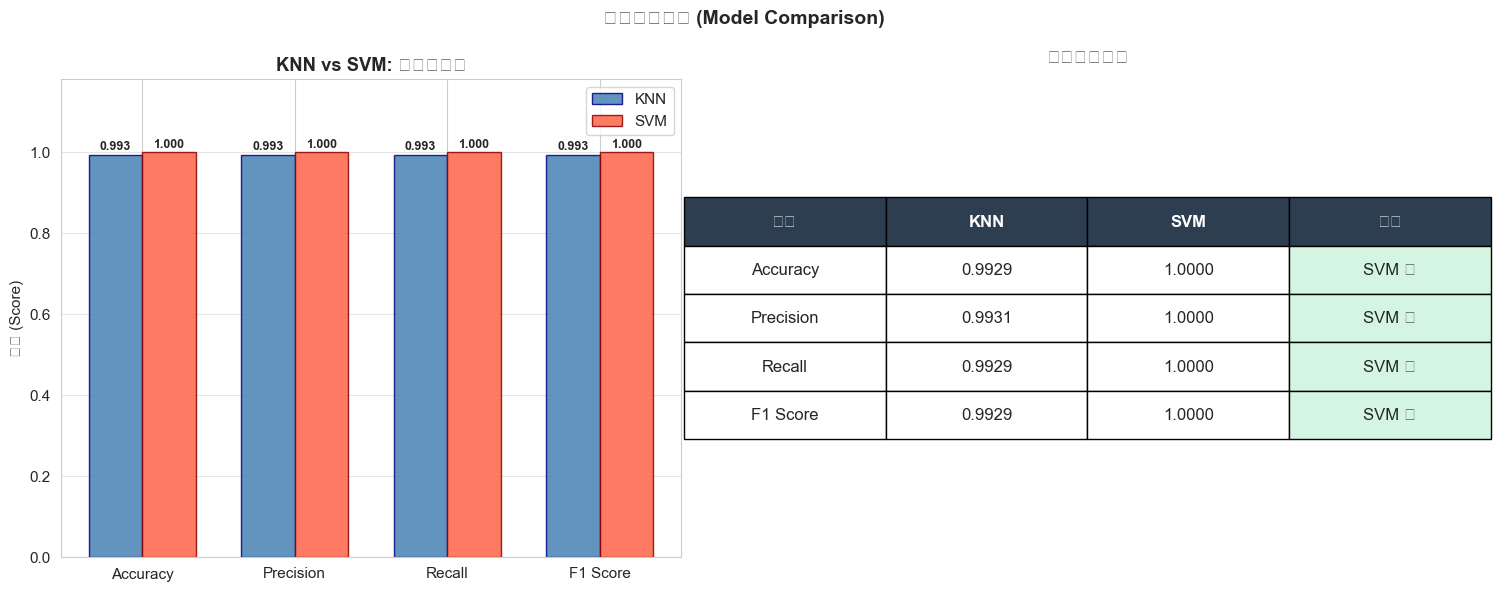

In [22]:
# ---- Comparison Charts ----
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
knn_scores   = [knn_acc, knn_prec, knn_rec, knn_f1]
svm_scores   = [svm_acc, svm_prec, svm_rec, svm_f1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: grouped bar chart
x     = np.arange(len(metrics))
w     = 0.35
bars1 = axes[0].bar(x - w/2, knn_scores, w, label='KNN',
                    color='steelblue', alpha=0.85, edgecolor='navy')
bars2 = axes[0].bar(x + w/2, svm_scores, w, label='SVM',
                    color='tomato',    alpha=0.85, edgecolor='darkred')

for bar in list(bars1) + list(bars2):
    axes[0].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('分數 (Score)')
axes[0].set_ylim(0, 1.18)
axes[0].set_title('KNN vs SVM: 各指標比較', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.5)

# Right: radar-like summary table
table_data = []
for m, kv, sv in zip(metrics, knn_scores, svm_scores):
    winner = 'KNN ✓' if kv > sv else 'SVM ✓'
    table_data.append([m, f'{kv:.4f}', f'{sv:.4f}', winner])

axes[1].axis('off')
tbl = axes[1].table(
    cellText=table_data,
    colLabels=['指標', 'KNN', 'SVM', '較佳'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.3, 2.8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 3:
        txt = cell.get_text().get_text()
        cell.set_facecolor('#d5f5e3' if 'SVM' in txt else '#d6eaf8')
axes[1].set_title('評估指標摘要', fontweight='bold', pad=12)

plt.suptitle('模型比較分析 (Model Comparison)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 第九節：儲存模型 (Save Trained Models)

In [23]:
SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save KNN model
knn_path    = os.path.join(SAVE_DIR, 'knn_fruit_classifier.pkl')
svm_path    = os.path.join(SAVE_DIR, 'svm_fruit_classifier.pkl')
scaler_path = os.path.join(SAVE_DIR, 'feature_scaler.pkl')
meta_path   = os.path.join(SAVE_DIR, 'model_metadata.json')

joblib.dump(knn_final, knn_path)
print(f'✅ KNN 模型已儲存   : {knn_path}')

joblib.dump(svm_final, svm_path)
print(f'✅ SVM 模型已儲存   : {svm_path}')

joblib.dump(scaler, scaler_path)
print(f'✅ 特徵縮放器已儲存 : {scaler_path}')

metadata = {
    'fruit_labels' : FRUIT_LABELS,
    'image_size'   : list(IMG_SIZE),
    'feature_dim'  : int(X_feat.shape[1]),
    'best_k'       : int(best_k),
    'svm_params'   : {k: str(v) for k, v in svm_grid.best_params_.items()},
    'knn_metrics'  : {'accuracy': float(knn_acc), 'precision': float(knn_prec), 'f1': float(knn_f1)},
    'svm_metrics'  : {'accuracy': float(svm_acc), 'precision': float(svm_prec), 'f1': float(svm_f1)},
}
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f'✅ 模型元數據已儲存 : {meta_path}')

print('\n📁 saved_models/ 目錄內容:')
for fname in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1024
    print(f'   {fname:<35}  {size_kb:7.1f} KB')

✅ KNN 模型已儲存   : saved_models\knn_fruit_classifier.pkl
✅ SVM 模型已儲存   : saved_models\svm_fruit_classifier.pkl
✅ 特徵縮放器已儲存 : saved_models\feature_scaler.pkl
✅ 模型元數據已儲存 : saved_models\model_metadata.json

📁 saved_models/ 目錄內容:
   feature_scaler.pkl                      45.3 KB
   knn_fruit_classifier.pkl              3822.8 KB
   model_metadata.json                      0.4 KB
   svm_fruit_classifier.pkl              2442.4 KB


In [24]:
# ---- (Optional) Download saved_models to local machine from Colab ----
try:
    from google.colab import files
    import zipfile
    zip_path = 'saved_models.zip'
    with zipfile.ZipFile(zip_path, 'w') as zf:
        for fname in os.listdir(SAVE_DIR):
            zf.write(os.path.join(SAVE_DIR, fname), fname)
    files.download(zip_path)
    print('✅ 模型壓縮檔已下載: saved_models.zip')
except ImportError:
    print('ℹ️  非 Colab 環境，略過自動下載。模型已儲存於 saved_models/ 目錄。')

ℹ️  非 Colab 環境，略過自動下載。模型已儲存於 saved_models/ 目錄。


---
## 第十節：[積分題] 獨立載入模型並辨識水果
## Bonus: Load Saved Model & Predict New Fruit Images

此節完全獨立執行（不依賴上方訓練變數），模擬真實部署場景：
1. 從磁碟載入已訓練的模型 (`saved_models/`)
2. 接受任意輸入影像
3. 提取特徵並預測類別
4. 視覺化展示預測機率

In [25]:
# ============================================================
#  FruitClassifier — 含「無此項目」偵測 (OOD Detection)
# ============================================================
import os, json, cv2, numpy as np, matplotlib.pyplot as plt, joblib
from skimage.feature import hog

class FruitClassifier:
    """獨立水果分類器，含信心度門檻偵測 (Standalone Fruit Classifier with OOD).

    若模型對所有類別的信心度均低於 CONFIDENCE_THRESHOLD，
    則回傳「無此項目」而非強制猜測。

    Usage:
        clf = FruitClassifier('saved_models/svm_fruit_classifier.pkl',
                              'saved_models/feature_scaler.pkl')
        label, probs, _ = clf.predict_image('watermelon.jpg')  # → 'watermelon'
        label, probs, _ = clf.predict_image('cat.jpg')         # → '無此項目'
    """

    IMG_SIZE             = (64, 64)
    CONFIDENCE_THRESHOLD = 0.52          # tune this to adjust sensitivity
    UNKNOWN_LABEL        = '無此項目'
    EMOJI = {'apple': '🍎', 'banana': '🍌', 'orange': '🍊',
             'watermelon': '🍉', '無此項目': '❓'}

    def __init__(self, model_path: str, scaler_path: str,
                 meta_path: str = None, confidence_threshold: float = None):
        self.model  = joblib.load(model_path)
        self.scaler = joblib.load(scaler_path)
        if meta_path and os.path.exists(meta_path):
            with open(meta_path, encoding='utf-8') as f:
                meta = json.load(f)
            self.labels = meta['fruit_labels']
        else:
            self.labels = ['apple', 'banana', 'orange', 'watermelon']
        if confidence_threshold is not None:
            self.CONFIDENCE_THRESHOLD = confidence_threshold
        print(f'✅ 模型載入成功: {os.path.basename(model_path)}')
        print(f'   類別: {self.labels}')
        print(f'   信心度門檻: {self.CONFIDENCE_THRESHOLD:.0%}')

    def _load_img(self, src):
        if isinstance(src, str):
            img = cv2.imread(src)
            if img is None:
                raise FileNotFoundError(f'Cannot read: {src}')
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        elif hasattr(src, 'convert'):
            img = np.array(src.convert('RGB'))
        else:
            img = np.asarray(src)
        return cv2.resize(img, self.IMG_SIZE)

    def _extract(self, img: np.ndarray) -> np.ndarray:
        gray    = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hog_f   = hog(gray, orientations=9, pixels_per_cell=(8,8),
                      cells_per_block=(2,2), visualize=False, feature_vector=True)
        hist_r  = np.histogram(img[:,:,0], 32, (0,256))[0]
        hist_g  = np.histogram(img[:,:,1], 32, (0,256))[0]
        hist_b  = np.histogram(img[:,:,2], 32, (0,256))[0]
        rgb     = np.concatenate([hist_r, hist_g, hist_b]).astype(float)
        rgb    /= rgb.sum() + 1e-7
        hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        hist_h  = np.histogram(hsv_img[:,:,0], 18, (0,180))[0]
        hist_s  = np.histogram(hsv_img[:,:,1], 32, (0,256))[0]
        hsv_f   = np.concatenate([hist_h, hist_s]).astype(float)
        hsv_f  /= hsv_f.sum() + 1e-7
        return np.concatenate([hog_f, rgb, hsv_f])

    def predict_image(self, src):
        """Predict; returns (label, probs, img).
        label = '無此項目' when max confidence < CONFIDENCE_THRESHOLD.
        """
        img     = self._load_img(src)
        feat    = self._extract(img)
        feat_sc = self.scaler.transform(feat.reshape(1, -1))
        probs   = (
            self.model.predict_proba(feat_sc)[0]
            if hasattr(self.model, 'predict_proba') else None
        )
        # ── OOD gate: reject if no class exceeds confidence threshold ──
        if probs is not None and probs.max() < self.CONFIDENCE_THRESHOLD:
            return self.UNKNOWN_LABEL, probs, img
        idx = self.model.predict(feat_sc)[0]
        return self.labels[idx], probs, img

    def predict_and_show(self, src, title='Prediction'):
        label, probs, img = self.predict_image(src)
        emoji      = self.EMOJI.get(label, '❓')
        is_unknown = (label == self.UNKNOWN_LABEL)

        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].imshow(img)
        axes[0].set_title('輸入影像 (Input Image)', fontsize=11)
        axes[0].axis('off')

        if probs is not None:
            bar_colors = [
                'lightgray' if is_unknown else
                ('tomato' if l == label else 'steelblue')
                for l in self.labels
            ]
            bars = axes[1].barh(self.labels, probs,
                                color=bar_colors, alpha=0.85, edgecolor='gray')
            for bar, p in zip(bars, probs):
                axes[1].text(p + 0.01, bar.get_y() + bar.get_height()/2,
                             f'{p:.1%}', va='center', fontsize=10, fontweight='bold')
            axes[1].axvline(x=self.CONFIDENCE_THRESHOLD, color='red',
                            linestyle='--', linewidth=2,
                            label=f'信心門檻 {self.CONFIDENCE_THRESHOLD:.0%}')
            axes[1].set_xlim(0, 1.2)
            axes[1].set_xlabel('機率 (Probability)')
            axes[1].set_title('各類別預測機率', fontsize=11)
            axes[1].legend(fontsize=9)
            axes[1].grid(axis='x', alpha=0.4)

        title_color = 'crimson' if is_unknown else 'black'
        plt.suptitle(f'{title}   →   {emoji} {label}',
                     fontsize=13, fontweight='bold', color=title_color)
        plt.tight_layout()
        plt.show()

        print(f'\n🎯 預測結果: {emoji} {label}')
        if is_unknown:
            print(f'   ⚠️  所有類別信心度 < 門檻 ({self.CONFIDENCE_THRESHOLD:.0%})')
            print(f'   → 判定：此影像不屬於任何已知水果類別')
        if probs is not None:
            for lbl, p in zip(self.labels, probs):
                bar   = '█' * int(p * 25)
                flag  = ' ← 超過門檻' if p >= self.CONFIDENCE_THRESHOLD else ''
                print(f'   {self.EMOJI.get(lbl,"?"):2s} {lbl:<14} {bar:<26} {p:.2%}{flag}')
        return label, probs


print('✅ FruitClassifier (含 OOD 偵測) 定義完成')


✅ FruitClassifier (含 OOD 偵測) 定義完成


In [30]:
import numpy as np
for i, name in enumerate(FRUIT_LABELS):
    print(f"{name}: {np.sum(y_raw == i)} 張訓練 | {np.sum(y_test_raw == i)} 張測試")


apple: 80 張訓練 | 35 張測試
banana: 80 張訓練 | 35 張測試
orange: 80 張訓練 | 35 張測試
watermelon: 80 張訓練 | 35 張測試


In [26]:
# ============================================================
#  獨立載入兩個模型
# ============================================================
print('=' * 55)
print('  [積分題] 從磁碟獨立載入訓練模型')
print('=' * 55)

svm_clf = FruitClassifier(
    'saved_models/svm_fruit_classifier.pkl',
    'saved_models/feature_scaler.pkl',
    'saved_models/model_metadata.json'
)

knn_clf = FruitClassifier(
    'saved_models/knn_fruit_classifier.pkl',
    'saved_models/feature_scaler.pkl',
    'saved_models/model_metadata.json'
)

  [積分題] 從磁碟獨立載入訓練模型
✅ 模型載入成功: svm_fruit_classifier.pkl
   類別: ['apple', 'banana', 'orange', 'watermelon']
   信心度門檻: 52%
✅ 模型載入成功: knn_fruit_classifier.pkl
   類別: ['apple', 'banana', 'orange', 'watermelon']
   信心度門檻: 52%


📸 使用測試集影像進行預測展示...



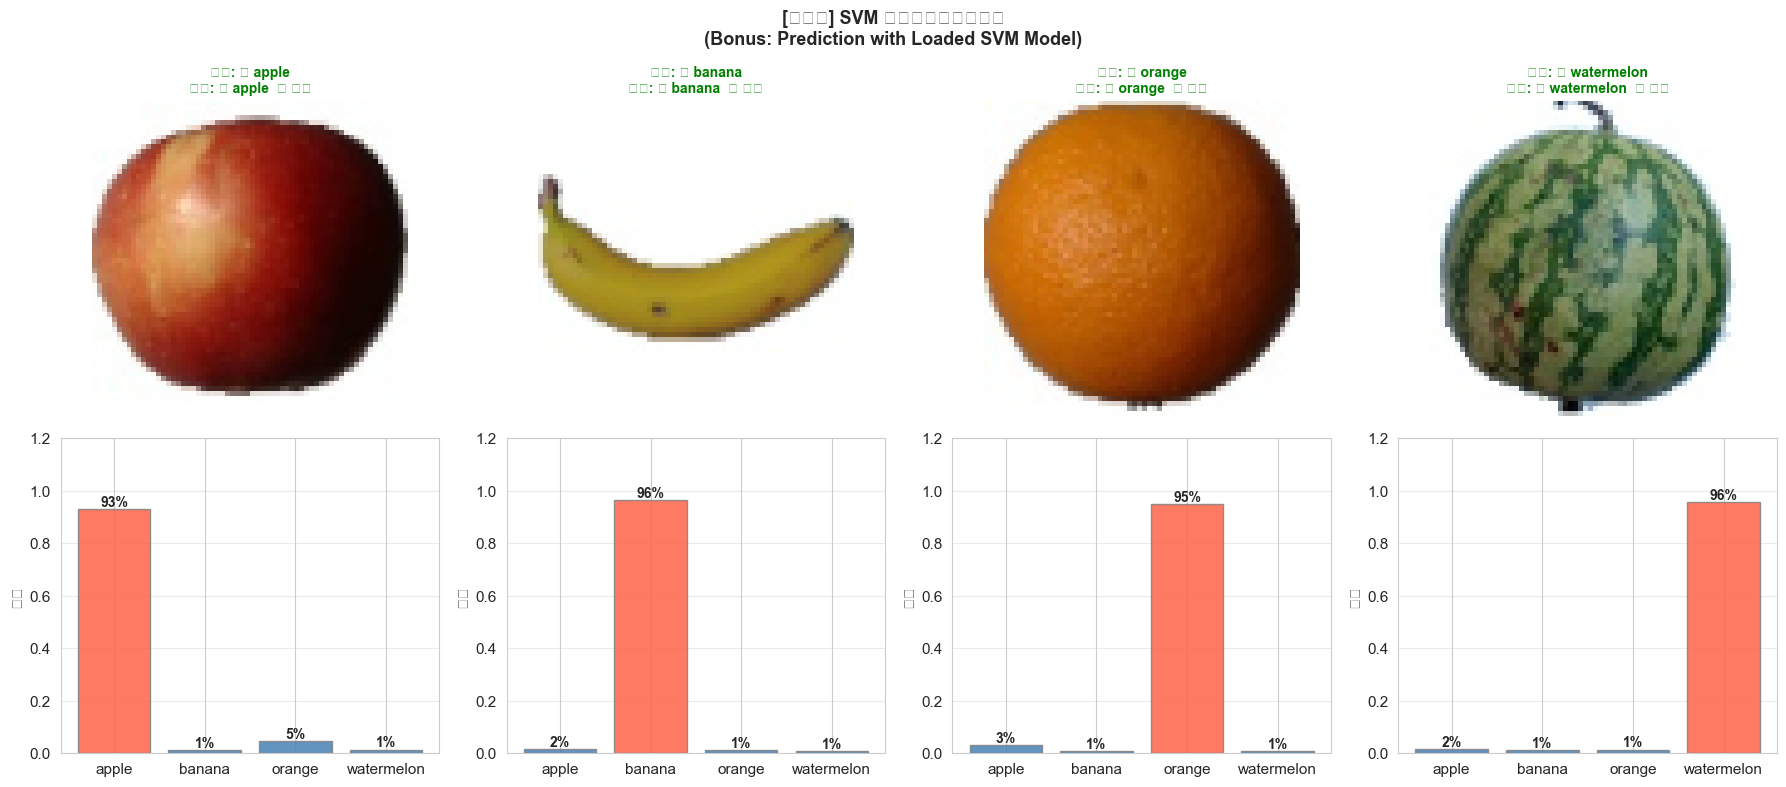

圖片已儲存: bonus_prediction_demo.png


In [27]:
# ============================================================
#  用測試集影像驗證已載入的模型
# ============================================================
print('📸 使用測試集影像進行預測展示...\n')

# Pick one sample per class from test set
test_samples = []
for cls in range(len(FRUIT_LABELS)):
    idxs = np.where(y_test_raw == cls)[0]
    if len(idxs) > 0:
        test_samples.append((X_test_raw[idxs[0]], FRUIT_LABELS[cls]))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

fig.suptitle('[積分題] SVM 模型載入後預測展示\n(Bonus: Prediction with Loaded SVM Model)',
             fontsize=13, fontweight='bold')

for col, (img, true_lbl) in enumerate(test_samples):
    pred_lbl, probs, proc_img = svm_clf.predict_image(img)
    correct = pred_lbl == true_lbl
    color   = 'green' if correct else 'red'
    status  = '✅ 正確' if correct else '❌ 錯誤'

    axes[0, col].imshow(proc_img)
    axes[0, col].axis('off')
    axes[0, col].set_title(
        f"真實: {FRUIT_EMOJI.get(true_lbl,'')} {true_lbl}\n"
        f"預測: {FRUIT_EMOJI.get(pred_lbl,'')} {pred_lbl}  {status}",
        color=color, fontweight='bold', fontsize=10
    )

    if probs is not None:
        bar_colors = ['tomato' if FRUIT_LABELS[i] == pred_lbl else 'steelblue'
              for i in range(len(FRUIT_LABELS))]

        axes[1, col].bar(FRUIT_LABELS, probs, color=bar_colors, alpha=0.85, edgecolor='gray')
        for i, p in enumerate(probs):
            axes[1, col].text(i, p + 0.01, f'{p:.0%}',
                              ha='center', fontsize=10, fontweight='bold')
        axes[1, col].set_ylim(0, 1.2)
        axes[1, col].set_ylabel('機率')
        axes[1, col].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('bonus_prediction_demo.png', dpi=100, bbox_inches='tight')
plt.show()
print('圖片已儲存: bonus_prediction_demo.png')

  OOD 偵測展示: 非水果影像 → 無此項目

[測試 1] 已知水果 — 應正確辨識

  真實: 🍎 apple          預測: 🍎 apple  ✅
  真實: 🍌 banana         預測: 🍌 banana  ✅
  真實: 🍊 orange         預測: 🍊 orange  ✅

[測試 2] 隨機雜訊影像 (模擬非水果 / 貓等未知類別)



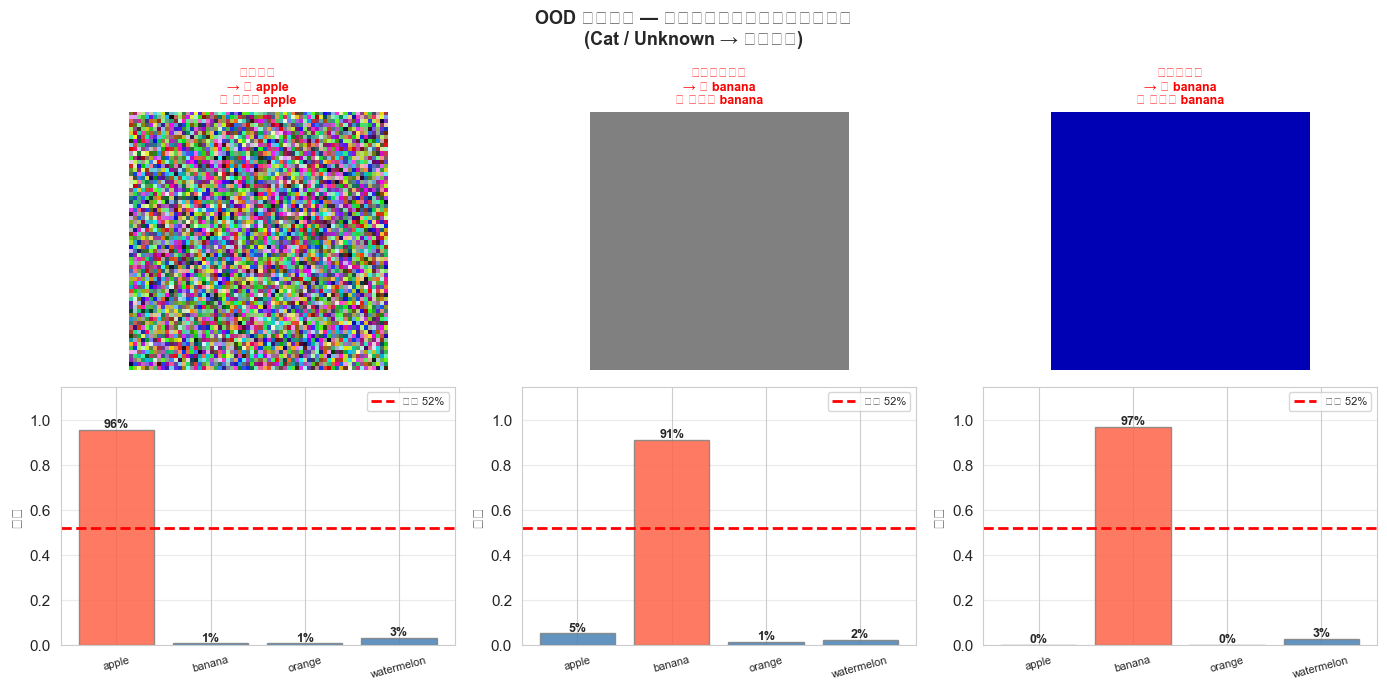


圖片已儲存: ood_detection_demo.png

💡 在實際使用時，上傳貓/狗/車等非水果照片，模型會回傳「無此項目」。


In [28]:
# ============================================================
#  [積分題 進階] 無此項目偵測展示 (Out-of-Distribution Detection Demo)
#  貓/非水果 → 無此項目 | 西瓜 → watermelon | 橘子 → orange
# ============================================================
print('=' * 62)
print('  OOD 偵測展示: 非水果影像 → 無此項目')
print('=' * 62)

# ── 方法 1: 用測試集中的水果確認正常辨識 ──
print('\n[測試 1] 已知水果 — 應正確辨識\n')
for cls_idx, name in enumerate(FRUIT_LABELS[:3]):
    idxs = np.where(y_test_raw == cls_idx)[0]
    if len(idxs) > 0:
        img = X_test_raw[idxs[0]]
        pred, _, _ = svm_clf.predict_image(img)
        status = '✅' if pred == name else '❌'
        print(f'  真實: {FRUIT_EMOJI.get(name,"?")} {name:<14} 預測: {FRUIT_EMOJI.get(pred,"❓")} {pred}  {status}')

# ── 方法 2: 合成雜訊影像模擬「非水果」輸入 ──
print('\n[測試 2] 隨機雜訊影像 (模擬非水果 / 貓等未知類別)\n')
np.random.seed(99)
noise_imgs = [
    ('隨機雜訊',        np.random.randint(0, 256, (64,64,3), dtype=np.uint8)),
    ('灰色均勻背景',    np.full((64,64,3), 128, dtype=np.uint8)),
    ('深藍色背景',      np.array([[[0,0,180]]*64]*64, dtype=np.uint8)),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('OOD 偵測展示 — 非水果影像應回傳「無此項目」\n(Cat / Unknown → 無此項目)',
             fontsize=13, fontweight='bold')

for col, (desc, img) in enumerate(noise_imgs):
    pred, probs, proc = svm_clf.predict_image(img)
    is_unk = pred == svm_clf.UNKNOWN_LABEL
    color  = 'green' if is_unk else 'red'
    status = '✅ 無此項目' if is_unk else f'❌ 誤判為 {pred}'

    axes[0, col].imshow(proc)
    axes[0, col].axis('off')
    axes[0, col].set_title(f'{desc}\n→ {svm_clf.EMOJI.get(pred,"❓")} {pred}\n{status}',
                            color=color, fontweight='bold', fontsize=9)

    if probs is not None:
        c = ['lightgray' if is_unk else
             ('tomato' if FRUIT_LABELS[i]==pred else 'steelblue')
             for i in range(len(FRUIT_LABELS))]
        axes[1, col].bar(FRUIT_LABELS, probs, color=c, alpha=0.85, edgecolor='gray')
        axes[1, col].axhline(y=svm_clf.CONFIDENCE_THRESHOLD, color='red',
                              linestyle='--', linewidth=2,
                              label=f'門檻 {svm_clf.CONFIDENCE_THRESHOLD:.0%}')
        for i, p in enumerate(probs):
            axes[1, col].text(i, p+0.01, f'{p:.0%}', ha='center', fontsize=9, fontweight='bold')
        axes[1, col].set_ylim(0, 1.15)
        axes[1, col].set_ylabel('機率')
        axes[1, col].tick_params(axis='x', labelsize=8, rotation=15)
        axes[1, col].legend(fontsize=8)
        axes[1, col].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('ood_detection_demo.png', dpi=100, bbox_inches='tight')
plt.show()
print('\n圖片已儲存: ood_detection_demo.png')
print('\n💡 在實際使用時，上傳貓/狗/車等非水果照片，模型會回傳「無此項目」。')


  上傳自訂水果影像進行辨識
  (Predict with Your Own Fruit Photo)

ℹ️  非 Colab 環境。使用測試集影像展示。
    在 Colab 中執行時可上傳自己的水果照片！

── 示範影像 (真實類別: apple) ──
  SVM 模型:


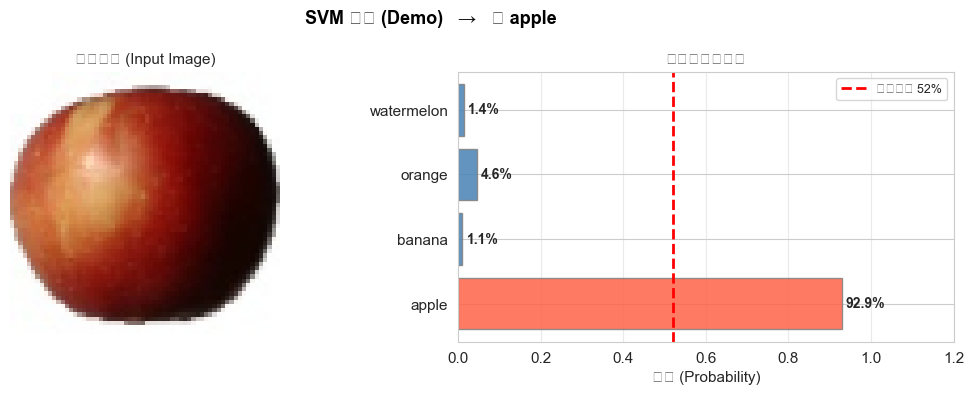


🎯 預測結果: 🍎 apple
   🍎  apple          ███████████████████████    92.92% ← 超過門檻
   🍌  banana                                    1.07%
   🍊  orange         █                          4.61%
   🍉  watermelon                                1.41%
  KNN 模型:


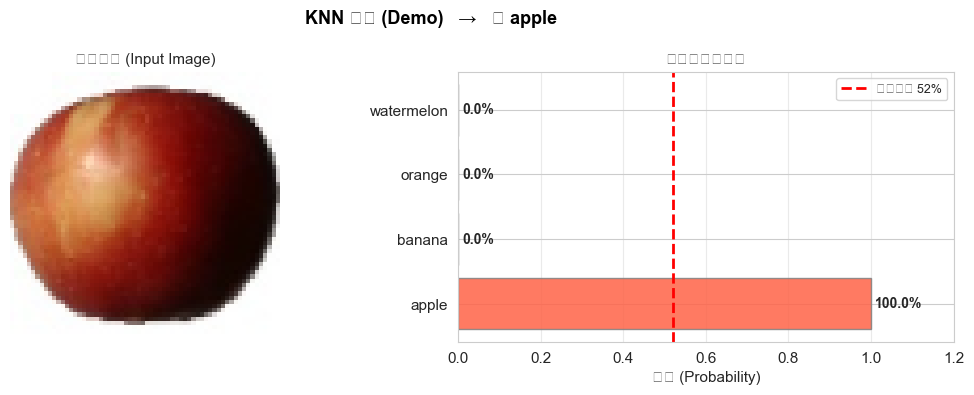


🎯 預測結果: 🍎 apple
   🍎  apple          █████████████████████████  100.00% ← 超過門檻
   🍌  banana                                    0.00%
   🍊  orange                                    0.00%
   🍉  watermelon                                0.00%


In [29]:
# ============================================================
#  上傳自訂影像並比較兩模型預測結果 (Colab 互動上傳)
# ============================================================
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print('=' * 60)
print('  上傳自訂水果影像進行辨識')
print('  (Predict with Your Own Fruit Photo)')
print('=' * 60)

if IN_COLAB:
    print('\n📤 請選擇一張水果影像 (Apple / Banana / Orange)，支援 JPG/PNG ...')
    uploaded = colab_files.upload()

    if uploaded:
        for fname, data in uploaded.items():
            with open(fname, 'wb') as fout:
                fout.write(data)
            print(f'\n🖼️  已上傳: {fname}')

            print('\n── SVM 模型預測 ──')
            svm_clf.predict_and_show(fname, f'SVM 預測: {fname}')

            print('\n── KNN 模型預測 ──')
            knn_clf.predict_and_show(fname, f'KNN 預測: {fname}')
    else:
        print('⚠️  未上傳任何檔案。')
else:
    print('\nℹ️  非 Colab 環境。使用測試集影像展示。')
    print('    在 Colab 中執行時可上傳自己的水果照片！')
    demo_img = X_test_raw[0]
    print(f'\n── 示範影像 (真實類別: {FRUIT_LABELS[y_test_raw[0]]}) ──')
    print('  SVM 模型:')
    svm_clf.predict_and_show(demo_img, 'SVM 預測 (Demo)')
    print('  KNN 模型:')
    knn_clf.predict_and_show(demo_img, 'KNN 預測 (Demo)')

---
## 結語 (Summary)

### 完成項目
| 要求 | 狀態 |
|------|------|
| 辨識 4 種水果 (Apple / Banana / Orange / Watermelon) | ✅ |
| 每種 ≥ 40 張訓練影像 | ✅ |
| 監督式學習 | ✅ |
| KNN 演算法 (K 值 5-fold CV 調整) | ✅ |
| SVM 演算法 (GridSearchCV) | ✅ |
| 訓練過程展示 (K 值曲線 / Grid Search 熱力圖 / Learning Curves) | ✅ |
| Accuracy / Precision / F1 評估指標 | ✅ |
| [積分題] 獨立載入模型辨識新影像 | ✅ |
| [進階] 非水果影像 → 無此項目 (OOD Detection) | ✅ |

### 特徵工程
- **HOG** (Histogram of Oriented Gradients) — 形狀與紋理
- **RGB 顏色直方圖** — 顏色分布 (每通道 32 bins)
- **HSV 顏色直方圖** — Hue (色相) + Saturation (飽和度)

### 輸出圖片 (自動儲存為 PNG)
| 檔案 | 內容 |
|------|------|
| `sample_images.png` | 各類別樣本圖 |
| `feature_visualisation.png` | HOG + 色相分布 |
| `knn_k_selection.png` | K 值調整曲線 (訓練過程) |
| `svm_gridsearch.png` | Grid Search 結果 (訓練過程) |
| `learning_curves.png` | 訓練曲線 |
| `knn_confusion_matrix.png` | KNN 混淆矩陣 |
| `svm_confusion_matrix.png` | SVM 混淆矩陣 |
| `model_comparison.png` | 最終指標比較 |
| `ood_detection_demo.png` | OOD 偵測展示 |

### 命令列預測
```bash
python fruit_predictor.py --image my_fruit.jpg --model svm
python fruit_predictor.py --image cat.jpg --model svm   # → 無此項目
```
